# Netflix Data Analytics Project 🎬
This project analyzes Netflix titles dataset to explore:
- Movies vs TV Shows distribution
- Top 10 Genres
- Content growth over years
- WordCloud of genres
- Missing values heatmap



In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from wordcloud import WordCloud

# Create folder to save images (if not exists)
os.makedirs("images", exist_ok=True)

In [2]:
# Load dataset

df = pd.read_csv("../data/netflix_titles.csv")


# Show first few rows and dataset info
print(df.head())
print(df.info())


  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [3]:
# Check missing values in dataset
print(df.isnull().sum())


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


## Visualization 1: Movies vs TV Shows
This chart shows the distribution of movies and TV shows available on Netflix.


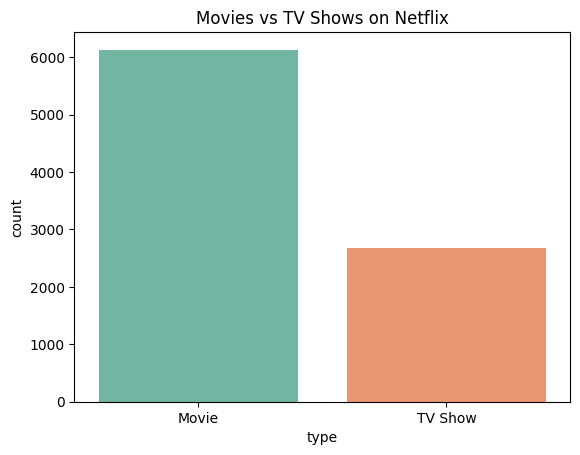

In [4]:
# Visualization 1 - Movies vs TV Shows
sns.countplot(x="type", data=df, hue="type", palette="Set2", legend=False)
plt.title("Movies vs TV Shows on Netflix")
plt.savefig("images/movies_vs_tvshows.png")
plt.show()


In [5]:
# Prepare genres column for analysis
df['listed_in'] = df['listed_in'].astype(str)
genres = df['listed_in'].str.split(',').explode()
top_genres = genres.value_counts().head(10)


## Visualization 2: Top 10 Genres
This bar chart highlights the most popular genres on Netflix, based on the number of titles.

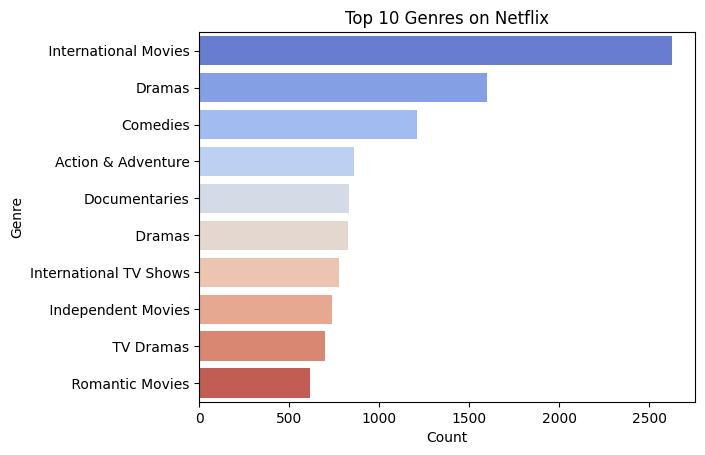

In [6]:
# Visualization 2 -Top 10 Genres

# Convert Series into DataFrame
top_genres_df = top_genres.reset_index()
top_genres_df.columns = ['Genre', 'Count']

# Plot with Seaborn (future-proof)
sns.barplot(x="Count", y="Genre", data=top_genres_df, hue="Genre", palette="coolwarm", legend=False)
plt.title("Top 10 Genres on Netflix")
plt.savefig("images/top_genres.png")
plt.show()


## Visualization 3: Content Growth Over Years
This histogram shows how Netflix’s content library has grown over the years, reflecting expansion trends.

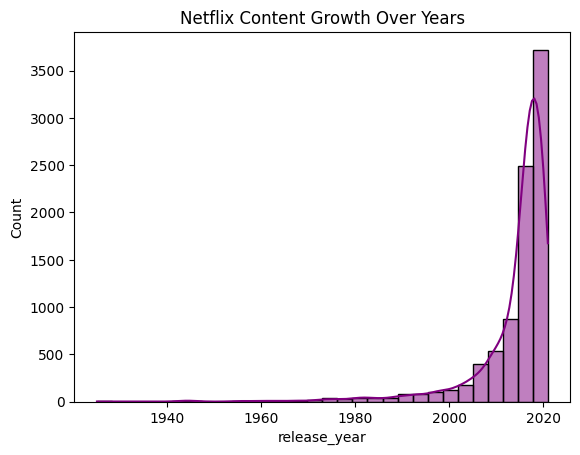

In [7]:
# Visualization 3 - Content Growth Over Years
df['release_year'] = pd.to_numeric(df['release_year'], errors='coerce')
sns.histplot(df['release_year'], bins=30, kde=True, color="purple")
plt.title("Netflix Content Growth Over Years")
plt.savefig("images/content_growth.png")
plt.show()


## Visualization 4: Genres WordCloud
This word cloud visualizes the genres on Netflix, where larger words represent more frequent genres.

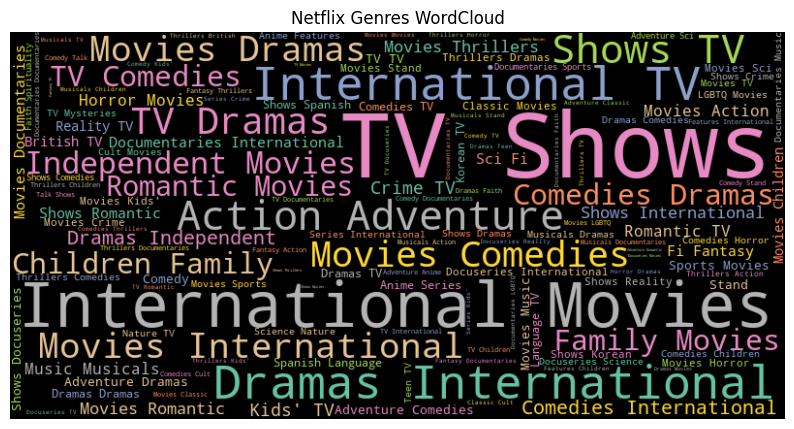

In [8]:
#Visualization 4 - Genres WordCloud
text = " ".join(genres)
wordcloud = WordCloud(width=800, height=400, background_color="black", colormap="Set2").generate(text)

plt.figure(figsize=(10,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Netflix Genres WordCloud")
plt.savefig("images/genres_wordcloud.png")
plt.show()


## Visualization 5: Missing Values Heatmap
This heatmap highlights missing values in the dataset, helping identify data quality issues.

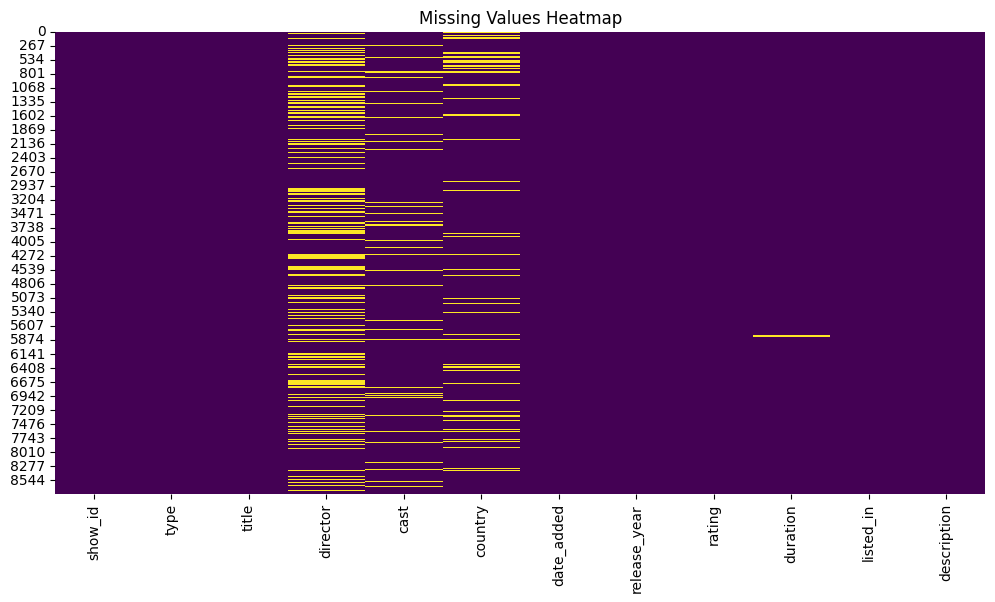

In [9]:
# Visualization 5 - Missing Values Heatmap

plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.savefig("images/missing_values_heatmap.png")
plt.show()


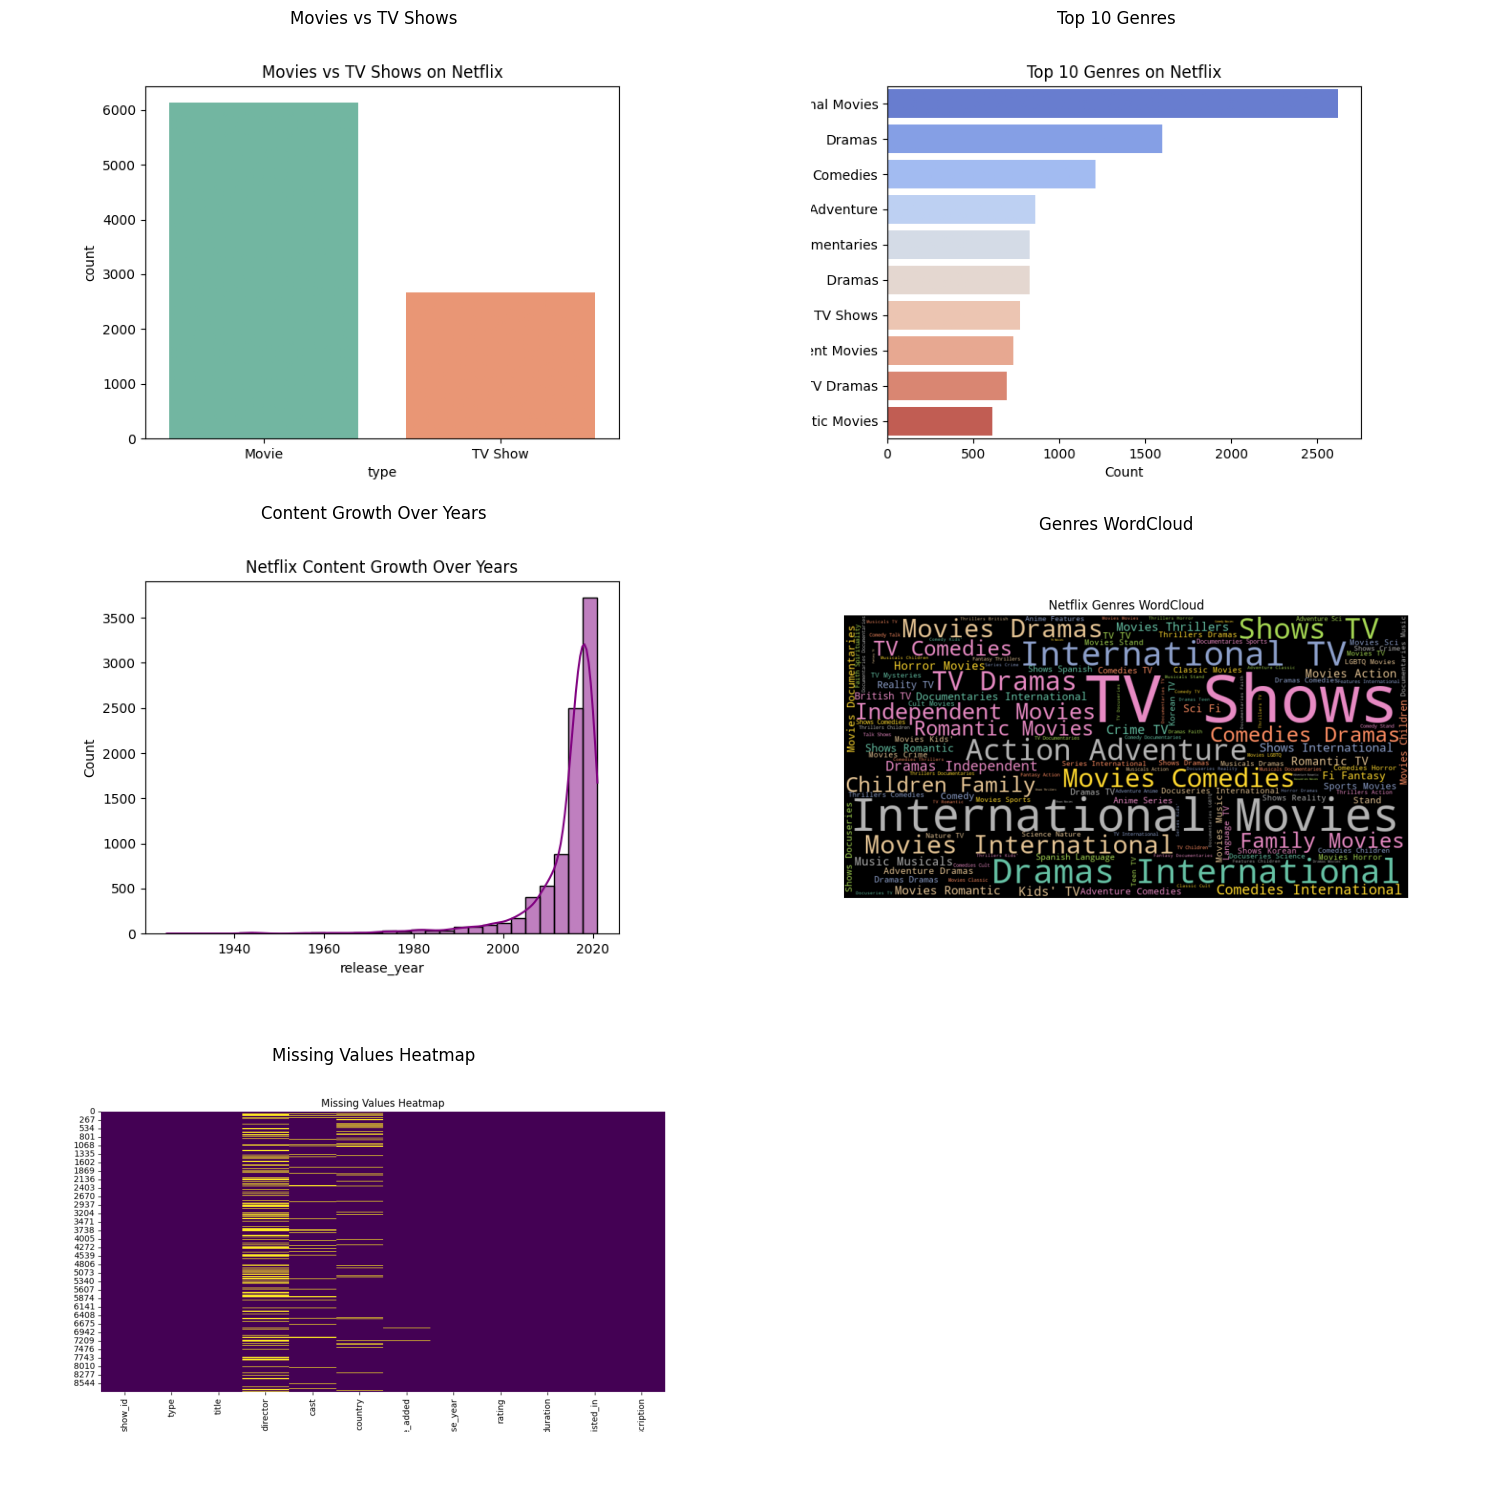

In [10]:
# Summary - Display All Saved Charts

import matplotlib.image as mpimg

fig, axes = plt.subplots(3, 2, figsize=(15,15))

# Movies vs TV Shows
axes[0,0].imshow(mpimg.imread("images/movies_vs_tvshows.png"))
axes[0,0].axis("off")
axes[0,0].set_title("Movies vs TV Shows")

# Top Genres
axes[0,1].imshow(mpimg.imread("images/top_genres.png"))
axes[0,1].axis("off")
axes[0,1].set_title("Top 10 Genres")

# Content Growth
axes[1,0].imshow(mpimg.imread("images/content_growth.png"))
axes[1,0].axis("off")
axes[1,0].set_title("Content Growth Over Years")

# Genres WordCloud
axes[1,1].imshow(mpimg.imread("images/genres_wordcloud.png"))
axes[1,1].axis("off")
axes[1,1].set_title("Genres WordCloud")

# Missing Values Heatmap
axes[2,0].imshow(mpimg.imread("images/missing_values_heatmap.png"))
axes[2,0].axis("off")
axes[2,0].set_title("Missing Values Heatmap")

# Hide empty subplot (since we have 5 charts, not 6)
axes[2,1].axis("off")

plt.tight_layout()
plt.show()

